In [14]:
import numpy as np
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [9]:
embeddings  = np.load('exps/eval_t1_hierarchical_split/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t1_hierarchical_split/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t1_hierarchical_split/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t1_hierarchical_split/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t1_hierarchical_split/hyp_match_flags.npy', allow_pickle=True)

print(type(embeddings), embeddings.dtype, len(embeddings))
print(type(labels), labels.dtype, len(labels))
print(type(scores), scores.dtype, len(scores))
print(type(match_flags), match_flags.dtype, len(match_flags))

print(embeddings[0].shape)
print(labels[0].shape)
print(scores[0].shape if len(scores) > 0 else "scores empty")
print(match_flags.shape)
print(match_flags.dtype)
print("total matched:", match_flags.sum())
print("images with at least one match:", (match_flags.sum(axis=1) > 0).sum())
print("first 20 per-image match counts:", match_flags.sum(axis=1)[:20])

<class 'numpy.ndarray'> float32 4952
<class 'numpy.ndarray'> int64 4952
<class 'numpy.ndarray'> float64 0
<class 'numpy.ndarray'> bool 4952
(100, 256)
(100,)
scores empty
(4952, 100)
bool
total matched: 36781
images with at least one match: 4952
first 20 per-image match counts: [ 4  3  4  1  2  9 14  5 25  5 21  4  2  2  3 13  9 14  5  1]


In [16]:
x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

print(x.shape)
print(y.shape)
print(m.shape)

counts = match_flags.sum(axis=1)
print("min:", counts.min(), "max:", counts.max(), "mean:", counts.mean())

print(f"class labels: {set(y)}")

(495200, 256)
(495200,)
(495200,)
min: 1 max: 63 mean: 7.427504038772213
class labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 80, -1}


In [ ]:
mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

superclass_map = {
    0:'vehicle', 1:'vehicle',
    2:'outdoor', 3:'outdoor',
    4:'animal', 5:'animal', 6:'animal',
    7:'accessory',
    8:'sports', 9:'sports',
    10:'kitchen', 11:'kitchen',
    12:'food', 13:'food',
    14:'furniture', 15:'furniture',
    16:'electronic',
    17:'appliance', 18:'appliance',
    19:'indoor',
}


sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

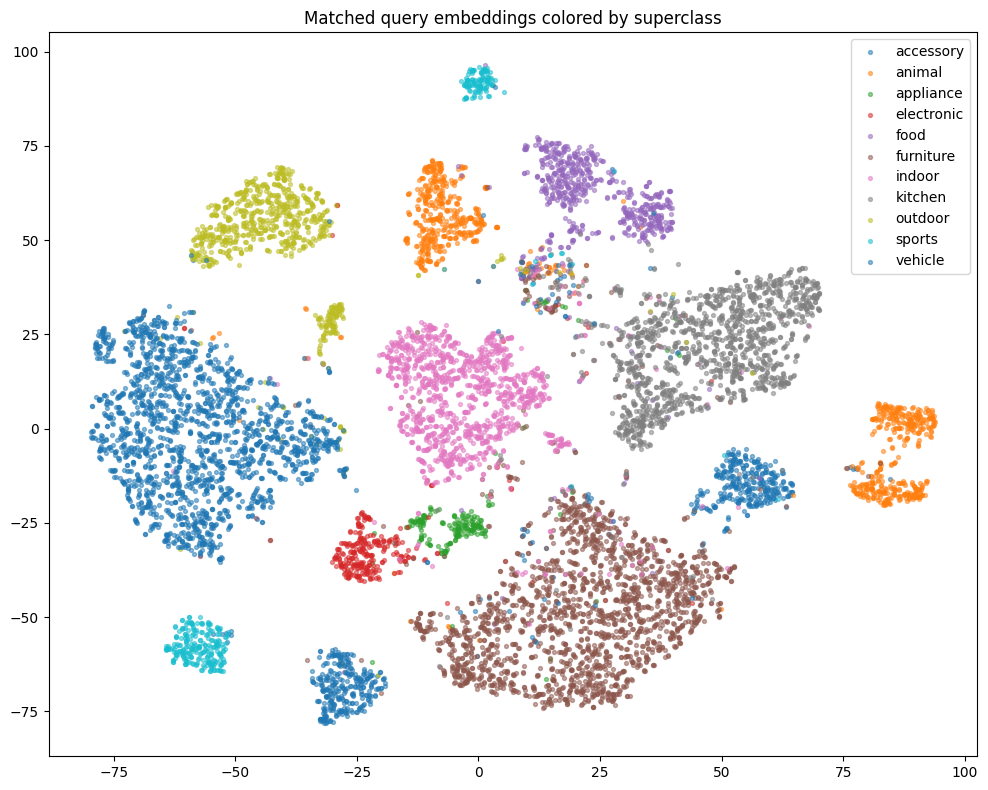

In [38]:
embeddings_pca = PCA(n_components=min(50, embeddings_known.shape[1]), random_state=42).fit_transform(embeddings_known)
Z = TSNE(n_components=2, init='pca', random_state=42, perplexity=25).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=sc)

plt.legend()
plt.title("Matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

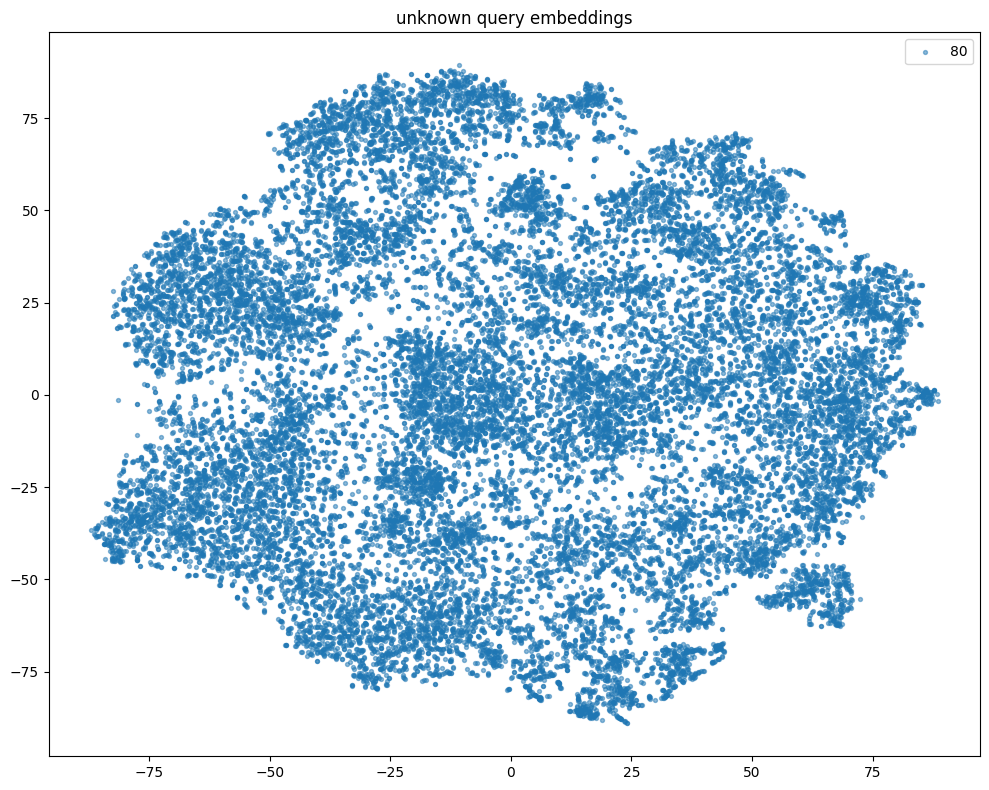

In [ ]:
embeddings_pca = PCA(n_components=min(50, embeddings_unknown.shape[1]), random_state=42).fit_transform(embeddings_unknown)
Z = TSNE(n_components=2, init='pca', random_state=42, perplexity=30).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(labels_unknown)):
    mask = labels_unknown == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=sc)

plt.legend()
plt.title("unknown query embeddings")
plt.tight_layout()
plt.show()

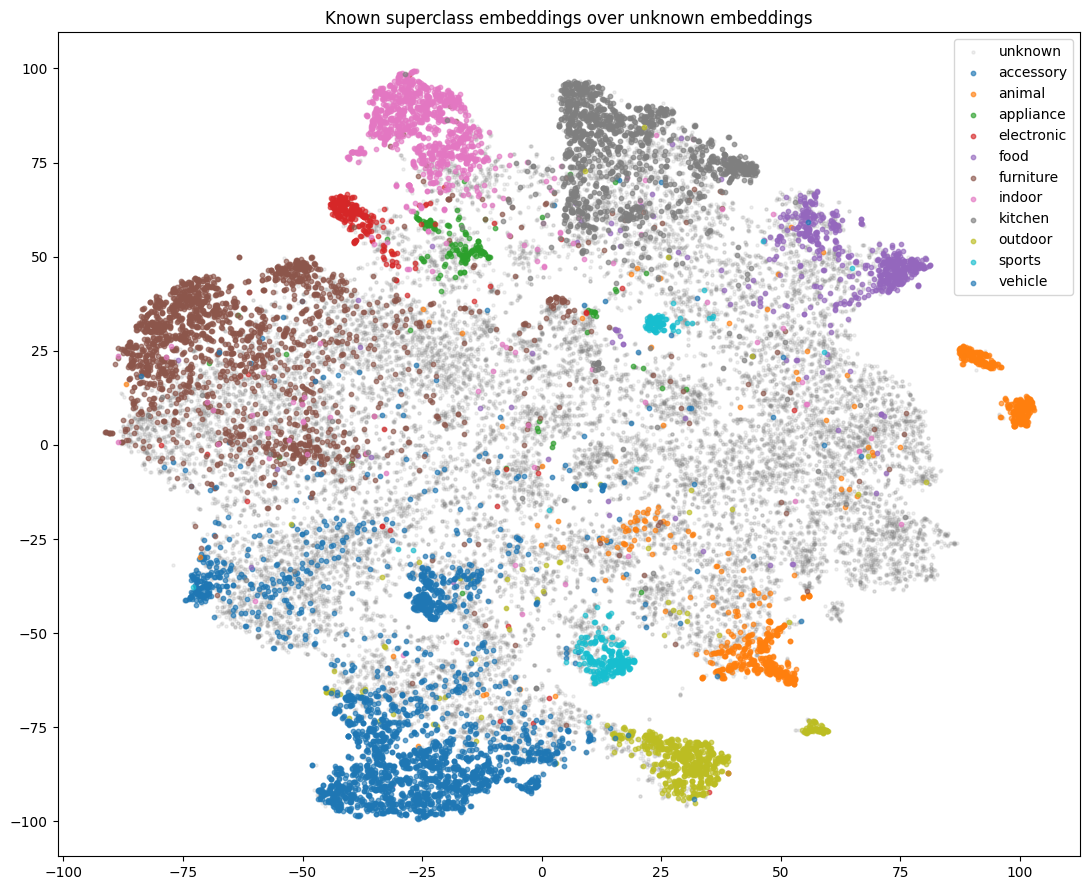

In [34]:
X_combined = np.vstack([embeddings_unknown, embeddings_known])

X_pca = PCA(
    n_components=min(50, X_combined.shape[1]),
    random_state=42
).fit_transform(X_combined)

Z_combined = TSNE(
    n_components=2,
    init='pca',
    random_state=42,
    perplexity=30
).fit_transform(X_pca)

n_unknown = len(embeddings_unknown)
Z_unknown = Z_combined[:n_unknown]
Z_known = Z_combined[n_unknown:]

plt.figure(figsize=(11, 9))

plt.scatter(
    Z_unknown[:, 0], Z_unknown[:, 1],
    s=5, alpha=0.12, c='gray', label='unknown'
)

for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(
        Z_known[mask, 0], Z_known[mask, 1],
        s=10, alpha=0.65, label=sc
    )

plt.legend()
plt.title("Known superclass embeddings over unknown embeddings")
plt.tight_layout()
plt.show()

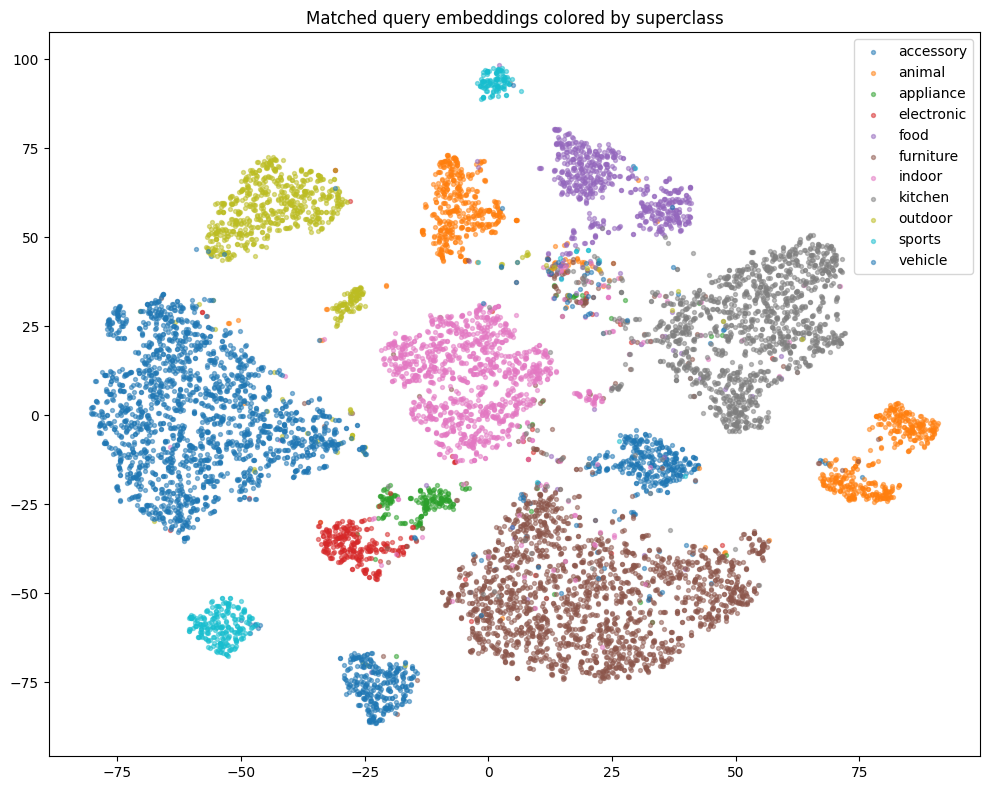

In [41]:
#********************EUCLIDEAN EMBEDDINGS************************
embeddings  = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

superclass_map = {
    0:'vehicle', 1:'vehicle',
    2:'outdoor', 3:'outdoor',
    4:'animal', 5:'animal', 6:'animal',
    7:'accessory',
    8:'sports', 9:'sports',
    10:'kitchen', 11:'kitchen',
    12:'food', 13:'food',
    14:'furniture', 15:'furniture',
    16:'electronic',
    17:'appliance', 18:'appliance',
    19:'indoor',
}


sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

embeddings_pca = PCA(n_components=min(50, embeddings_known.shape[1]), random_state=42).fit_transform(embeddings_known)
Z = TSNE(n_components=2, init='pca', random_state=42, perplexity=25).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=sc)

plt.legend()
plt.title("Matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

class labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 80, -1}


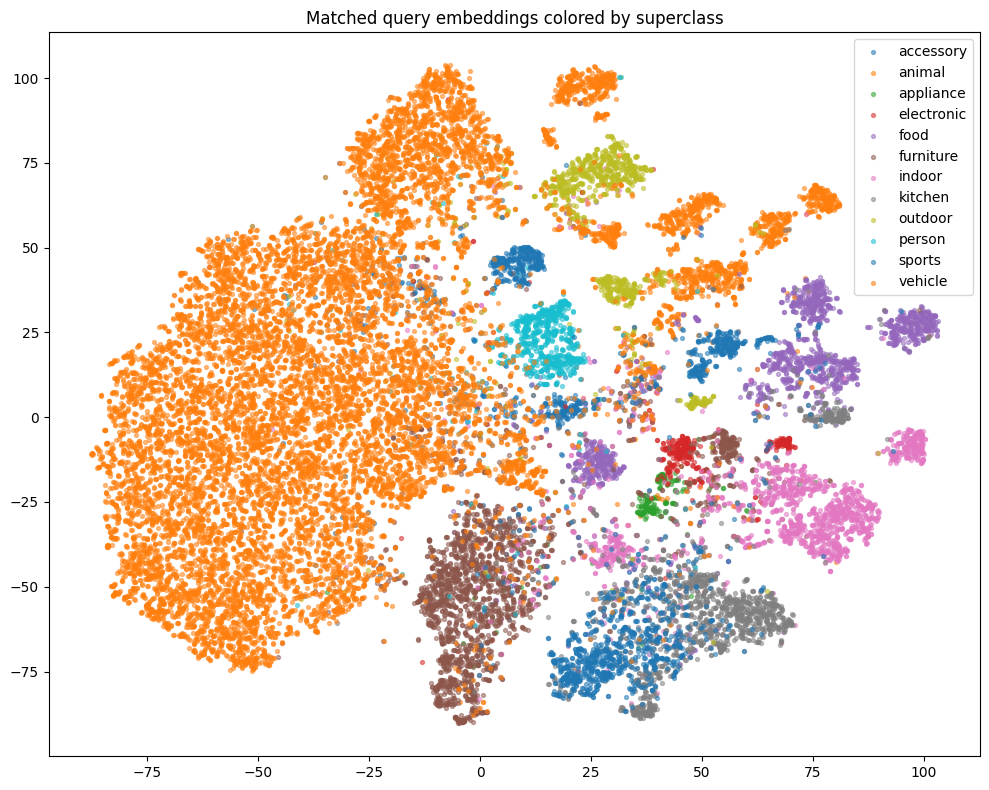

In [44]:
#********************TASK 2 EUCLIDEAN EMBEDDINGS************************
embeddings  = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
print(f"class labels: {set(y)}")
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

superclass_map = {
    0:'person', 
    1:'vehicle',
    2:'outdoor', 
    3:'outdoor',
    4:'animal', 
    5:'animal', 
    6:'animal',
    7:'accessory',
    8:'sports', 
    9:'sports',
    10:'kitchen', 
    11:'kitchen',
    12:'food', 
    13:'food',
    14:'furniture', 
    15:'furniture',
    16:'electronic',
    17:'appliance', 
    18:'appliance',
    19:'indoor',
    20:'vehicle', 
    #end task 1
    21:'person',
    22:'vehicle', 
    23:'vehicle',
    24:'outdoor', 
    25:'animal', 
    26:'animal',
    27:'accessory',
    28:'sports', 
    29:'sports',
    30:'kitchen', 
    31:'food',
    32:'food', 
    33:'food',
    34:'furniture', 
    35:'furniture',
    36:'electronic',
    37:'appliance', 
    38:'indoor',
    39:'indoor',
}


sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

embeddings_pca = PCA(n_components=min(50, embeddings_known.shape[1]), random_state=42).fit_transform(embeddings_known)
Z = TSNE(n_components=2, init='pca', random_state=42, perplexity=25).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, label=sc)

plt.legend()
plt.title("Matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

In [ ]:
#construct superclass prototypes, determine drift between task 1 and task 2 prototypes

